# 6CS012 – Artificial Intelligence and Machine Learning
## Final Portfolio Project 2026
### (Sentiment Analysis) Text Classification with RNN.
####2408994
#####Shreya Bhatta

# Install Dependencies & GPU Check

In [6]:
# Install required libraries
# We remove the strict numpy==1.23.5 pin to avoid build errors in modern Python
!pip install --upgrade pip setuptools wheel -q
!pip install gensim gradio wordcloud nltk -U -q

print("All packages installed. Restart runtime if prompted, then continue from next cell.")

All packages installed. Restart runtime if prompted, then continue from next cell.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [8]:
# All imports used throughout the notebook
import os
import re
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# NLTK for text preprocessing
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Gensim for pre-trained GloVe embeddings
import gensim.downloader as api

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPUs found  : {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow  : 2.20.0
GPUs found  : 1


# Load Dataset

In [9]:

DATASET_DIR = '/content/drive/MyDrive/AI ML/MovieReview/5. Movie Review Dataset-20260430T151229Z-3-001'

TRAIN_PATH = os.path.join(DATASET_DIR, '/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/train_movie_review.csv')
TEST_PATH  = os.path.join(DATASET_DIR, '/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/test_movie_review.csv')
VAL_PATH   = os.path.join(DATASET_DIR, '/content/drive/MyDrive/AI ML/Task3/5. Movie Review Dataset/val_movie_review.csv')

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
df_val   = pd.read_csv(VAL_PATH)

# Standardise column names
for df in [df_train, df_test, df_val]:
    df.columns = df.columns.str.strip().str.lower()

print(f"Train : {df_train.shape}")
print(f"Val   : {df_val.shape}")
print(f"Test  : {df_test.shape}")
df_train.head(3)

Train : (35000, 3)
Val   : (5000, 3)
Test  : (10000, 3)


,unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0


In [10]:
# Drop unlabelled rows - task says to drop any data not labelled 0 or 1
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    before = len(df)
    df.dropna(subset=['sentiment'], inplace=True)
    dropped = before - len(df[df['sentiment'].isin([0, 1])])
    print(f"{name}: {dropped} unlabelled rows dropped")

df_train = df_train[df_train['sentiment'].isin([0, 1])].reset_index(drop=True)
df_val   = df_val[df_val['sentiment'].isin([0, 1])].reset_index(drop=True)
df_test  = df_test[df_test['sentiment'].isin([0, 1])].reset_index(drop=True)

# Combine all splits; we re-split 80/20 as the task requires
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all.dropna(subset=['review', 'sentiment'], inplace=True)
df_all['sentiment'] = df_all['sentiment'].astype(int)

print(f"\nTotal samples : {len(df_all)}")
print(f"Class balance :\n{df_all['sentiment'].value_counts()}")

train: 0 unlabelled rows dropped
val: 0 unlabelled rows dropped
test: 0 unlabelled rows dropped

Total samples : 50000
Class balance :
sentiment
0    25000
1    25000
Name: count, dtype: int64


# Text Preprocessing, Tokenisation & Padding

In [11]:
# Contraction map: expand before removing special characters
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't":  "will not", "can't": "cannot", "couldn't": "could not",
    "shouldn't": "should not", "wouldn't": "would not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "you'll": "you will", "you'd": "you would", "he's": "he is",
    "she's": "she is", "they're": "they are", "they've": "they have",
    "they'll": "they will", "they'd": "they would", "we're": "we are",
    "we've": "we have", "we'll": "we will", "we'd": "we would",
    "that's": "that is", "there's": "there is", "let's": "let us",
    "what's": "what is", "who's": "who is", "how's": "how is",
    "would've": "would have", "could've": "could have",
    "should've": "should have", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'ve": " have",
}

STOP_WORDS = set(stopwords.words('english'))

# Remove negation words from stopwords list
NEGATION_WORDS = {
    'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing',
    'nowhere', 'none', 'cannot', 'couldn', 'didn', 'doesn', 'don',
    'hadn', 'hasn', 'haven', 'isn', 'mightn', 'mustn', 'needn',
    'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn',
    'very', 'too', 'so', 'more', 'most', 'less', 'least',
    'but', 'however', 'although', 'though', 'despite'
}
STOP_WORDS = STOP_WORDS - NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def expand_contractions(text: str) -> str:
    """Replace contractions with full forms before cleaning."""
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text


def clean_text(text: str) -> str:
    """
    Full preprocessing pipeline applied to every review:
      1. Lowercase
      2. Strip HTML tags (IMDb data has <br /> tags etc.)
      3. Expand contractions
      4. Remove URLs
      5. Remove @mentions and #hashtags
      6. Remove numbers
      7. Remove all remaining special characters
      8. Tokenise, remove stopwords, lemmatize, drop short tokens
    """
    text = str(text).lower()                           # 1
    text = re.sub(r'<.*?>', ' ', text)                 # 2 HTML
    text = expand_contractions(text)                   # 3
    text = re.sub(r'http\S+|www\.\S+', ' ', text)     # 4 URLs
    text = re.sub(r'@\w+', ' ', text)                  # 5 mentions
    text = re.sub(r'#\w+', ' ', text)                  # 5 hashtags
    text = re.sub(r'\d+', ' ', text)                   # 6 numbers
    text = re.sub(r'[^a-z\s]', ' ', text)              # 7 special chars
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 2]   # 8 stopwords + lemmatize
    return ' '.join(tokens)


# Sanity check
sample = "I don't think this film was great! Check https://imdb.com for #reviews @user"
print(f"Before: {sample}")
print(f"After : {clean_text(sample)}")

Before: I don't think this film was great! Check https://imdb.com for #reviews @user
After : not think film great check


In [12]:
# Apply cleaning to the full dataset
print("Cleaning text... please wait")
df_all['clean_review'] = df_all['review'].apply(clean_text)

# Drop any reviews that became empty after cleaning
df_all = df_all[df_all['clean_review'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Samples remaining after cleaning: {len(df_all)}")
df_all[['review', 'clean_review', 'sentiment']].head(3)

Cleaning text... please wait
Samples remaining after cleaning: 50000


,review,clean_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema but buying dvd wif...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0


#  Data Visualisation

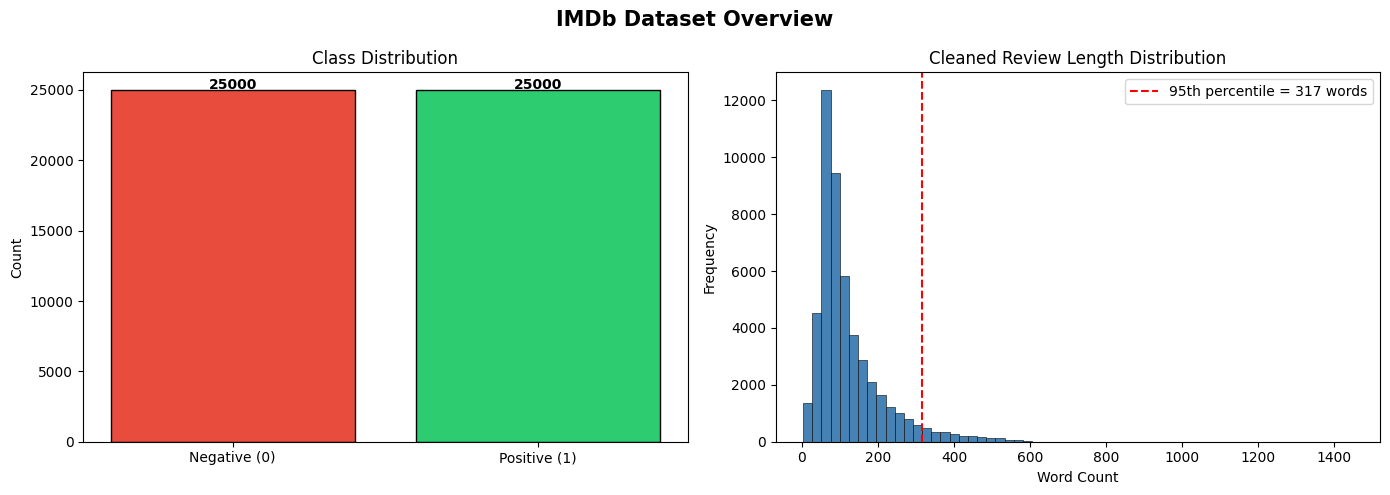

95th percentile length: 317 words


In [13]:
# Review length distribution + class balance
df_all['review_len'] = df_all['clean_review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IMDb Dataset Overview', fontsize=15, fontweight='bold')

# Class balance
counts = df_all['sentiment'].value_counts()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

# Length distribution
axes[1].hist(df_all['review_len'], bins=60, color='steelblue', edgecolor='black', linewidth=0.4)
p95 = np.percentile(df_all['review_len'], 95)
axes[1].axvline(p95, color='red', linestyle='--', label=f'95th percentile = {int(p95)} words')
axes[1].set_title('Cleaned Review Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"95th percentile length: {int(p95)} words")

In [14]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df_all['clean_review'] = df_all['review'].apply(clean_text)

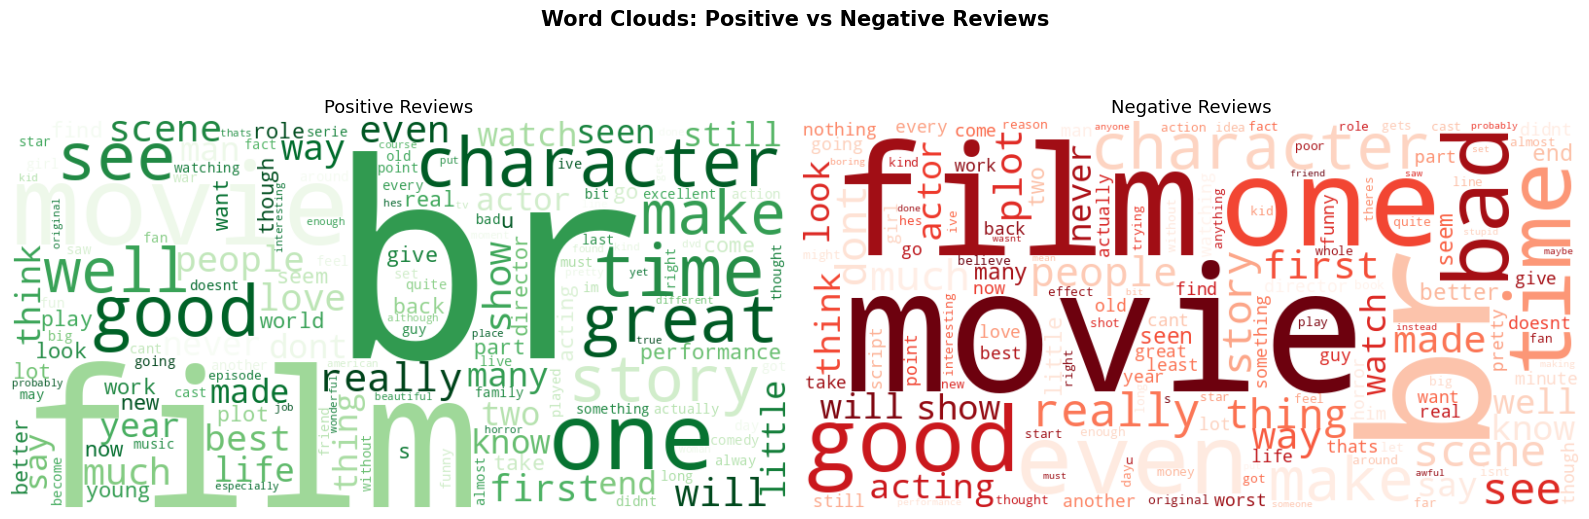

In [15]:
# Word clouds - positive vs negative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds: Positive vs Negative Reviews', fontsize=15, fontweight='bold')

for idx, (label, cmap, title) in enumerate([
    (1, 'Greens', 'Positive Reviews'),
    (0, 'Reds',   'Negative Reviews')
]):
    text_blob = ' '.join(df_all[df_all['sentiment'] == label]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=150,
                   collocations=False).generate(text_blob)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(title, fontsize=13)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

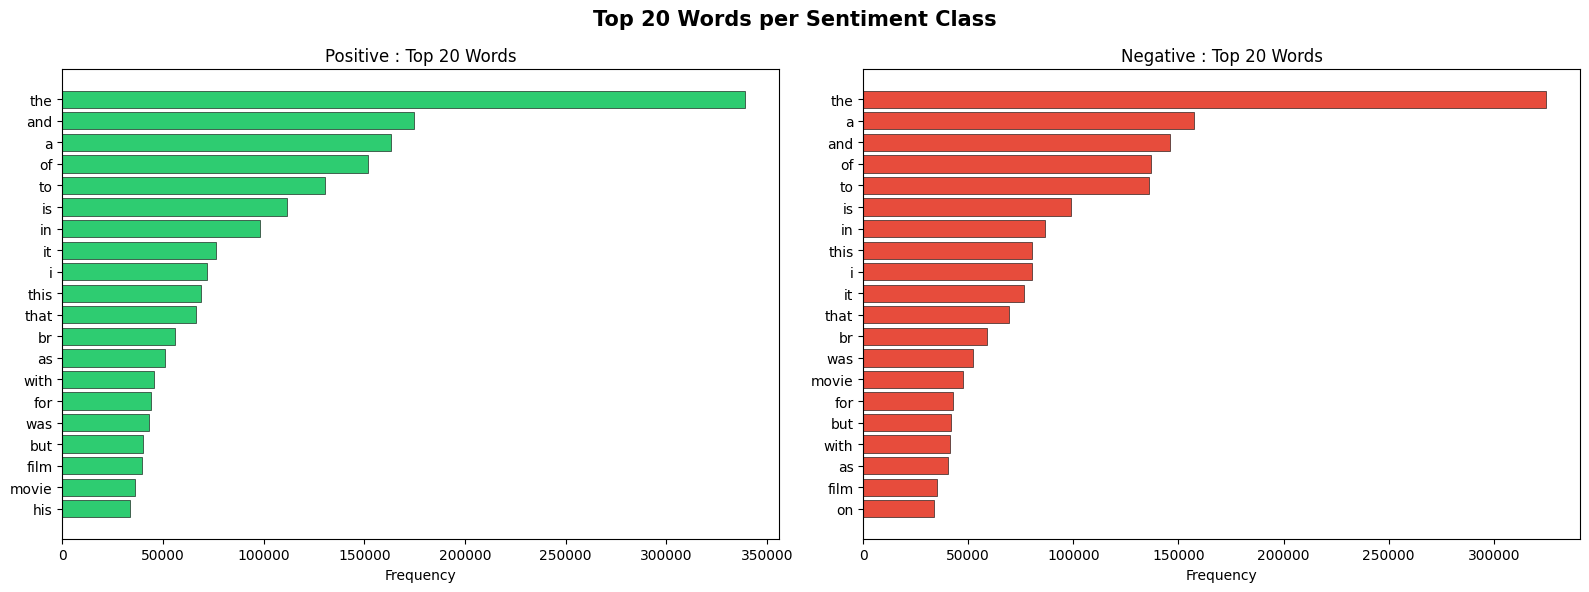

In [16]:
# Top 20 most frequent words per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Words per Sentiment Class', fontsize=15, fontweight='bold')

for idx, (label, color, title) in enumerate([
    (1, '#2ecc71', 'Positive'),
    (0, '#e74c3c', 'Negative')
]):
    words_list = ' '.join(df_all[df_all['sentiment'] == label]['clean_review']).split()
    freq = Counter(words_list).most_common(20)
    words, counts = zip(*freq)
    axes[idx].barh(list(reversed(words)), list(reversed(counts)),
                   color=color, edgecolor='black', linewidth=0.4)
    axes[idx].set_title(f'{title} : Top 20 Words')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

# Train/Test Split + Tokenisation + Padding

In [17]:
X = df_all['clean_review'].values
y = df_all['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing  samples  : {len(X_test)}")
print(f"Train class dist  : {Counter(y_train)}")
print(f"Val   class dist  : {Counter(y_val)}")
print(f"Test  class dist  : {Counter(y_test)}")

Training samples  : 35000
Validation samples: 7500
Testing  samples  : 7500
Train class dist  : Counter({np.int64(1): 17500, np.int64(0): 17500})
Val   class dist  : Counter({np.int64(0): 3750, np.int64(1): 3750})
Test  class dist  : Counter({np.int64(0): 3750, np.int64(1): 3750})


In [18]:
VOCAB_SIZE = 20000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f"Total unique words in training data : {len(word_index):,}")
print(f"Vocabulary size used                : {VOCAB_SIZE:,}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

MAX_LEN = int(np.percentile([len(s) for s in X_train_seq], 95))
print(f"\nPadding length (95th percentile) : {MAX_LEN} tokens")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad   shape : {X_val_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

Total unique words in training data : 144,921
Vocabulary size used                : 20,000

Padding length (95th percentile) : 590 tokens

X_train_pad shape : (35000, 590)
X_val_pad   shape : (7500, 590)
X_test_pad  shape : (7500, 590)


# Model Building

In [19]:
# Shared hyperparameters for all models
VOCAB_SIZE    = 20000
EMBEDDING_DIM = 128
RNN_UNITS     = 64
LSTM_UNITS    = 64
DROPOUT_RATE  = 0.5
LEARNING_RATE = 3e-4
BATCH_SIZE    = 128
MAX_EPOCHS    = 20

print("Hyperparameters defined")

Hyperparameters defined


In [20]:
model1 = Sequential(name='Model1_BiSimpleRNN')
model1.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN))
model1.add(Bidirectional(SimpleRNN(RNN_UNITS,
                                   kernel_regularizer=l2(0.001),
                                   recurrent_regularizer=l2(0.001))))
model1.add(Dropout(0.5))
model1.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model1.add(Dropout(0.3))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)
model1.summary()

Model: "Model1_BiSimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model2 = Sequential(name='Model2_BiLSTM')
model2.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN))
model2.add(Dropout(0.4))
model2.add(Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)))
model2.add(Dropout(0.4))
model2.add(Bidirectional(LSTM(LSTM_UNITS)))
model2.add(Dropout(0.5))
model2.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)
model2.summary()

Model: "Model2_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
# glove-wiki-gigaword-200: 200-dimensional
print("Downloading GloVe embeddings (glove-wiki-gigaword-200)...")
GLOVE_DIM   = 200
glove_model = api.load('glove-wiki-gigaword-200')
print(f"GloVe loaded | Vocab size: {len(glove_model.key_to_index):,}")

[==================================================] 100.0% 252.1/252.1MB downloaded
GloVe loaded | Vocab size: 400,000


In [23]:
# Build the embedding matrix by mapping each word in our tokeniser vocabulary to its corresponding GloVe vector
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:   # skip words outside our vocab limit
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        misses += 1   # words not in GloVe stay as zero vectors

coverage = hits / min(VOCAB_SIZE, len(word_index)) * 100
print(f"GloVe coverage  : {hits:,} / {hits+misses:,} words ({coverage:.1f}%)")
print(f"Embedding matrix: {embedding_matrix.shape}")

GloVe coverage  : 18,780 / 19,999 words (93.9%)
Embedding matrix: (20000, 200)


In [24]:
model3 = Sequential(name='Model3_BiLSTM_GloVe_Finetuned')
model3.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=GLOVE_DIM,
                     weights=[embedding_matrix],
                     input_length=MAX_LEN,
                     trainable=False))
model3.add(Dropout(0.3))
model3.add(Bidirectional(LSTM(128, return_sequences=True)))
model3.add(Dropout(0.3))
model3.add(Bidirectional(LSTM(64)))
model3.add(Dropout(0.4))
model3.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)
model3.summary()

Model: "Model3_BiLSTM_GloVe_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     4,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,000,000 (15.26 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,000,000 (15.26 MB)

# Model Training

In [25]:
def get_callbacks(patience=3):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [26]:
import time

#Model 1
print("=" * 50)
print("  Training Model 1: SimpleRNN")
print("=" * 50)
t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks(patience=4),
    verbose=1
)
time1 = time.time() - t0
print(f"\nModel 1 done : {time1:.1f}s | Best val_acc: {max(history1.history['val_accuracy'])*100:.2f}%")

  Training Model 1: SimpleRNN
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 36s 109ms/step - accuracy: 0.5907 - loss: 0.9683 - val_accuracy: 0.7564 - val_loss: 0.7949 - learning_rate: 3.0000e-04
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.8089 - loss: 0.7036 - val_accuracy: 0.8479 - val_loss: 0.6169 - learning_rate: 3.0000e-04
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.8513 - loss: 0.6012 - val_accuracy: 0.8163 - val_loss: 0.6743 - learning_rate: 3.0000e-04
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - accuracy: 0.8960 - loss: 0.4740 - val_accuracy: 0.8507 - val_loss: 0.5506 - learning_rate: 3.0000e-04
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.8860 - loss: 0.4764 - val_accuracy: 0.8604 - val_loss: 0.5225 - learning_rate: 3.0000e-04
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.8920 - loss: 0.4270 - val_accuracy: 0.8005 - val_loss: 0.5948 - learning_rate: 3.0000e-04
Epoch 7/20
274/274 ━━

In [27]:
#  Model 2
print("=" * 50)
print("  Training Model 2: LSTM")
print("=" * 50)
t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks(patience=3),
    verbose=1
)
time2 = time.time() - t0
print(f"\nModel 2 done : {time2:.1f}s | Best val_acc: {max(history2.history['val_accuracy'])*100:.2f}%")

  Training Model 2: LSTM
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 40s 120ms/step - accuracy: 0.7095 - loss: 0.5656 - val_accuracy: 0.8728 - val_loss: 0.3362 - learning_rate: 3.0000e-04
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.8979 - loss: 0.2938 - val_accuracy: 0.8879 - val_loss: 0.3057 - learning_rate: 3.0000e-04
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 32s 116ms/step - accuracy: 0.9258 - loss: 0.2294 - val_accuracy: 0.8831 - val_loss: 0.3069 - learning_rate: 3.0000e-04
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9323 - loss: 0.2071
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
274/274 ━━━━━━━━━━━━━━━━━━━━ 32s 117ms/step - accuracy: 0.9358 - loss: 0.1971 - val_accuracy: 0.8780 - val_loss: 0.3122 - learning_rate: 3.0000e-04
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.9559 - loss: 0.1462 - val_accuracy: 0.8919 - val_loss: 0.3323 - learning_rate: 1.5000e-04
Epoch 5: early stopping
Res

In [28]:
import time

print("=" * 55)
print("  Training Model 3: BiLSTM + GloVe (Two-Stage)")
print("=" * 55)
t0 = time.time()

# Stage 1: frozen GloVe - warm up LSTM layers
print("\nStage 1: Frozen GloVe : training LSTM layers...")
history3_s1 = model3.fit(
    X_train_pad, y_train,
    epochs=8,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks(patience=3),
    verbose=1
)

# Stage 2: unfreeze GloVe and fine-tune everything
print("\nStage 2: Unfreezing GloVe for fine-tuning...")
model3.layers[0].trainable = True

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=2e-4),
    metrics=['accuracy']
)

history3_s2 = model3.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=get_callbacks(patience=4),
    verbose=1
)

time3 = time.time() - t0

combined_history = {}
for key in history3_s1.history:
    combined_history[key] = history3_s1.history[key] + history3_s2.history[key]

class CombinedHistory:
    def __init__(self, h): self.history = h

history3 = CombinedHistory(combined_history)
best_val = max(combined_history['val_accuracy'])
print(f"\nModel 3 done : {time3:.1f}s | Best val_acc: {best_val*100:.2f}%")

  Training Model 3: BiLSTM + GloVe (Two-Stage)

Stage 1: Frozen GloVe : training LSTM layers...
Epoch 1/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 53s 178ms/step - accuracy: 0.6807 - loss: 0.6563 - val_accuracy: 0.6440 - val_loss: 0.6417 - learning_rate: 3.0000e-04
Epoch 2/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.7579 - loss: 0.5527 - val_accuracy: 0.7575 - val_loss: 0.5812 - learning_rate: 3.0000e-04
Epoch 3/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.6871 - loss: 0.5981 - val_accuracy: 0.7183 - val_loss: 0.5914 - learning_rate: 3.0000e-04
Epoch 4/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.6634 - loss: 0.6349 - val_accuracy: 0.7897 - val_loss: 0.4843 - learning_rate: 3.0000e-04
Epoch 5/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.7569 - loss: 0.5337 - val_accuracy: 0.8028 - val_loss: 0.4587 - learning_rate: 3.0000e-04
Epoch 6/8
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.7883 - loss: 0.4824 - val_accuracy: 0.8212 - v

# Training Curves (Loss & Accuracy)

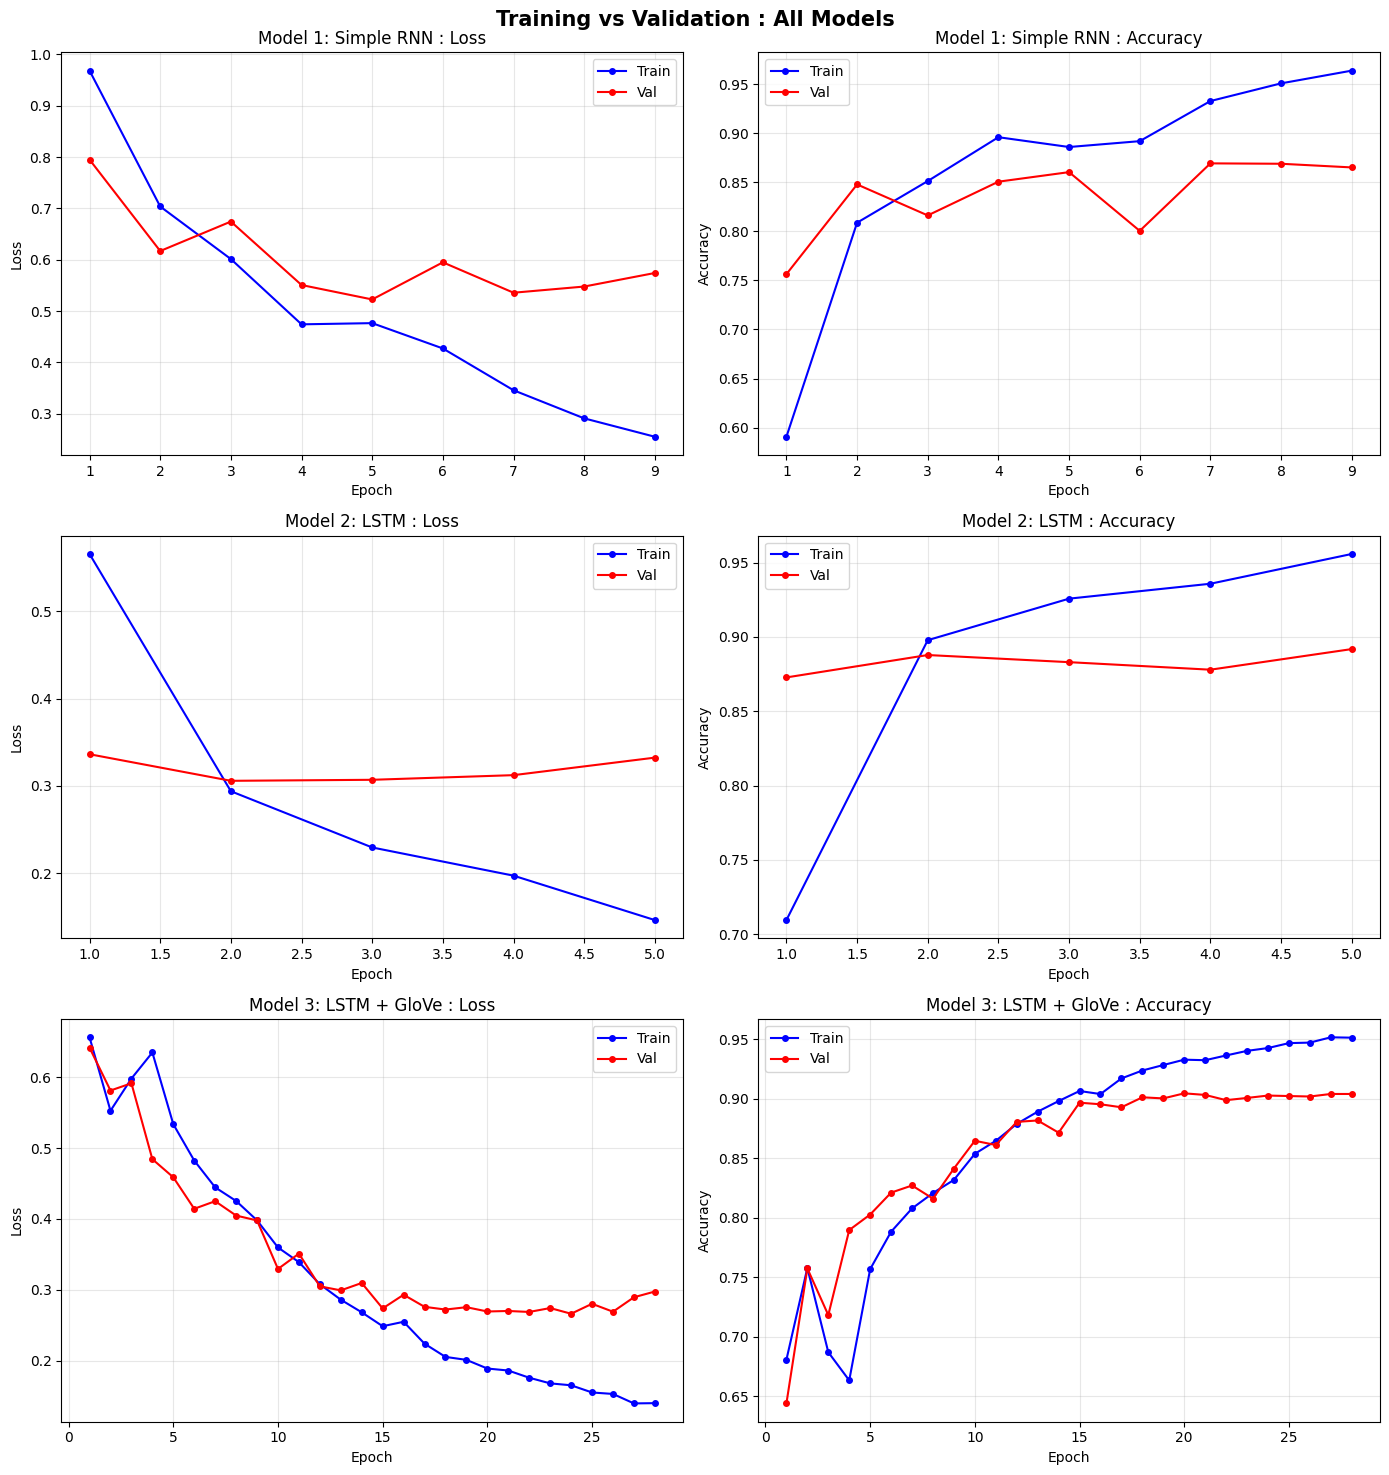

In [29]:
def plot_history(history, model_name, ax_loss, ax_acc):
    """Plots train vs val loss and accuracy on the given axes."""
    epochs = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs, history.history['loss'],     'b-o', markersize=4, label='Train')
    ax_loss.plot(epochs, history.history['val_loss'], 'r-o', markersize=4, label='Val')
    ax_loss.set_title(f'{model_name} : Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs, history.history['accuracy'],     'b-o', markersize=4, label='Train')
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r-o', markersize=4, label='Val')
    ax_acc.set_title(f'{model_name} : Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)


fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle('Training vs Validation : All Models', fontsize=15, fontweight='bold')

plot_history(history1, 'Model 1: Simple RNN',   axes[0][0], axes[0][1])
plot_history(history2, 'Model 2: LSTM',          axes[1][0], axes[1][1])
plot_history(history3, 'Model 3: LSTM + GloVe',  axes[2][0], axes[2][1])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#  Evaluation (Accuracy, Confusion Matrix, Classification Report)

In [30]:
def evaluate_model(model, X_pad, y_true, model_name):
    """
    Full evaluation of a trained model:
    - Test accuracy
    - Classification report (precision, recall, F1 per class)
    - Returns predicted labels and probabilities
    """
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")

    y_proba = model.predict(X_pad, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Negative', 'Positive']))
    return y_pred, y_proba


y_pred1, y_prob1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1: Simple RNN')
y_pred2, y_prob2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2: LSTM')
y_pred3, y_prob3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3: LSTM + GloVe')


  Model 1: Simple RNN

Test Accuracy : 0.8564  (85.64%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.87      0.86      3750
    Positive       0.87      0.84      0.85      3750

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500


  Model 2: LSTM

Test Accuracy : 0.8836  (88.36%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.83      0.88      3750
    Positive       0.85      0.93      0.89      3750

    accuracy                           0.88      7500
   macro avg       0.89      0.88      0.88      7500
weighted avg       0.89      0.88      0.88      7500


  Model 3: LSTM + GloVe

Test Accuracy : 0.9032  (90.32%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      375

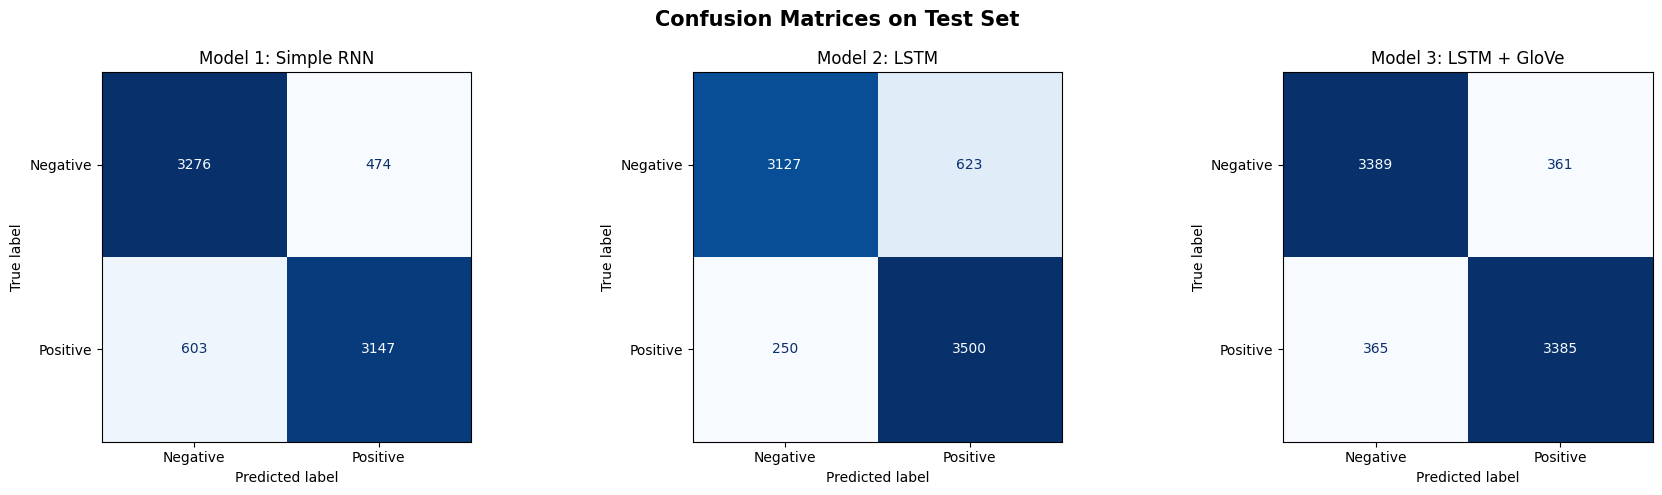

In [31]:
# Confusion matrices of all three side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices on Test Set', fontsize=15, fontweight='bold')

for ax, y_pred, title in zip(
    axes,
    [y_pred1, y_pred2, y_pred3],
    ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

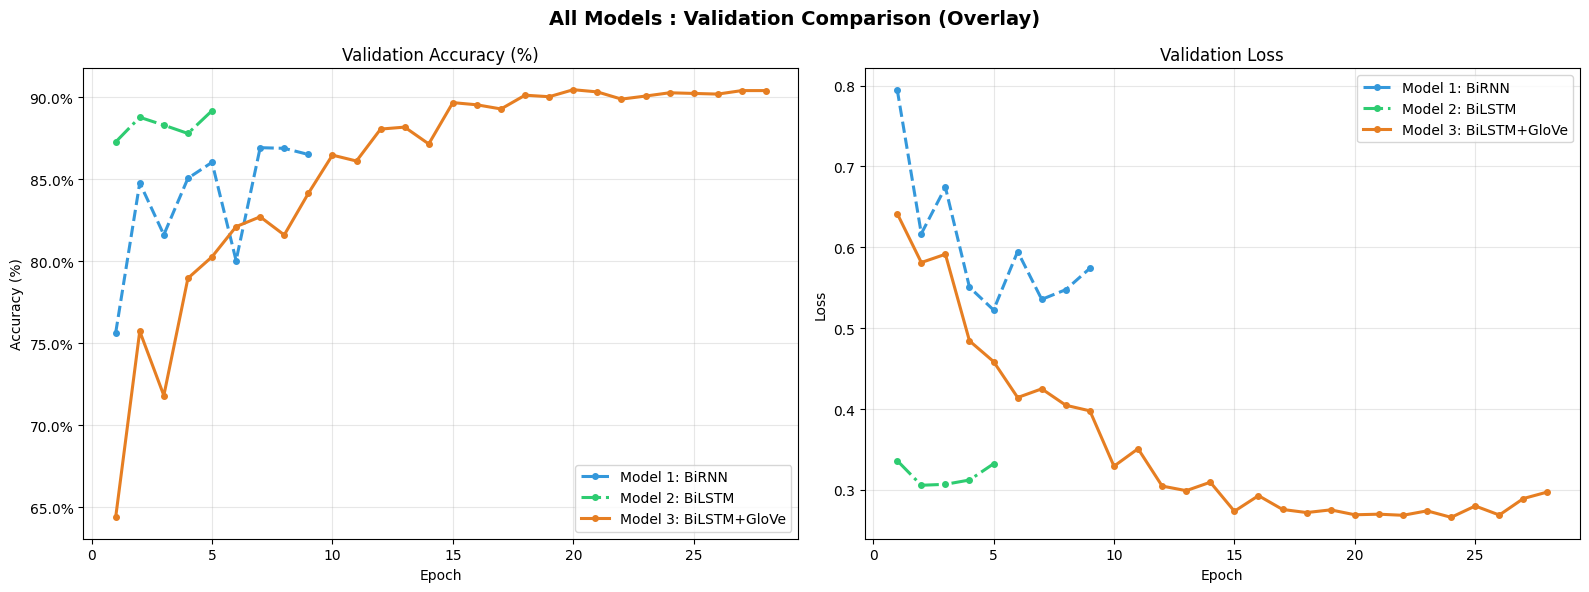

In [32]:
# overlay all 3 val curves on one chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('All Models : Validation Comparison (Overlay)', fontsize=14, fontweight='bold')

styles = [
    ('Model 1: BiRNN',        history1, '#3498db', '--'),
    ('Model 2: BiLSTM',       history2, '#2ecc71', '-.'),
    ('Model 3: BiLSTM+GloVe', history3, '#e67e22', '-'),
]

for label, history, colour, ls in styles:
    ep = range(1, len(history.history['val_accuracy']) + 1)
    axes[0].plot(ep, [v*100 for v in history.history['val_accuracy']],
                 color=colour, linestyle=ls, linewidth=2.2,
                 marker='o', markersize=4, label=label)
    axes[1].plot(ep, history.history['val_loss'],
                 color=colour, linestyle=ls, linewidth=2.2,
                 marker='o', markersize=4, label=label)

axes[0].set_title('Validation Accuracy (%)', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

axes[1].set_title('Validation Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overlay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

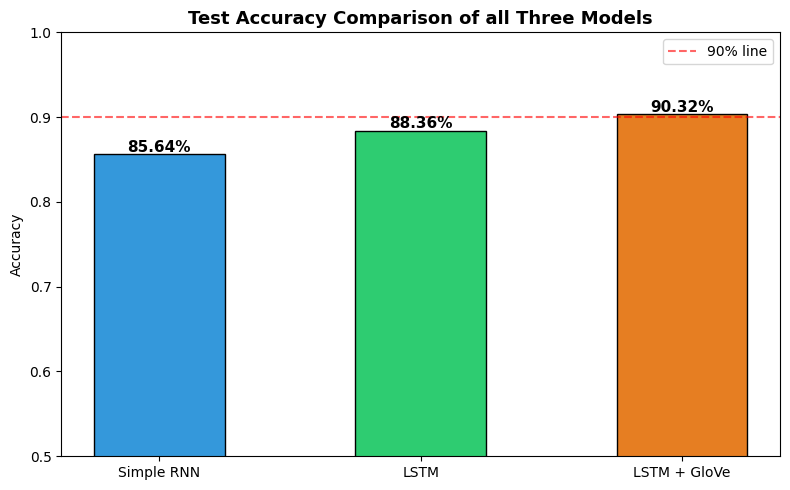

In [33]:
# Model comparison bar chart - test accuracy
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
test_accs   = [
    accuracy_score(y_test, y_pred1),
    accuracy_score(y_test, y_pred2),
    accuracy_score(y_test, y_pred3),
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, test_accs,
              color=['#3498db', '#2ecc71', '#e67e22'],
              edgecolor='black', width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_title('Test Accuracy Comparison of all Three Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.axhline(0.9, color='red', linestyle='--', alpha=0.6, label='90% line')
ax.legend()

for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{acc*100:.2f}%',
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

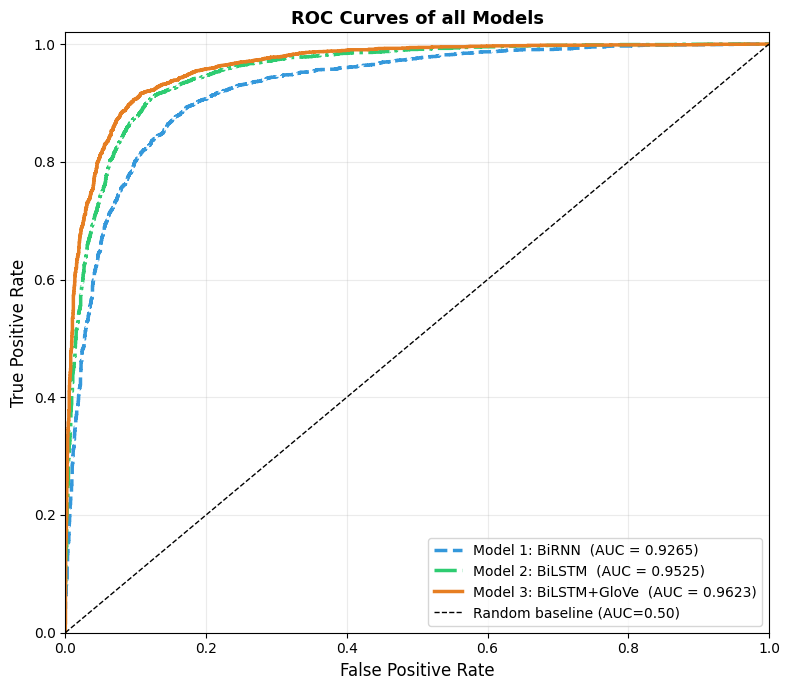

In [34]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))

for label, y_prob, colour, ls in [
    ('Model 1: BiRNN',        y_prob1, '#3498db', '--'),
    ('Model 2: BiLSTM',       y_prob2, '#2ecc71', '-.'),
    ('Model 3: BiLSTM+GloVe', y_prob3, '#e67e22', '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linestyle=ls, linewidth=2.5,
            label=f'{label}  (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random baseline (AUC=0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves of all Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras import backend as K

summary_data = []
for name, model, yp, yprob, hist, t in [
    ('Bi-SimpleRNN',   model1, y_pred1, y_prob1, history1, time1),
    ('Bi-LSTM',        model2, y_pred2, y_prob2, history2, time2),
    ('Bi-LSTM+GloVe',  model3, y_pred3, y_prob3, history3, time3),
]:
    total     = model.count_params()
    trainable = sum(K.count_params(w) for w in model.trainable_weights)
    summary_data.append({
        'Model'           : name,
        'Test Acc (%)'    : f"{accuracy_score(y_test, yp)*100:.2f}",
        'AUC'             : f"{roc_auc_score(y_test, yprob):.4f}",
        'F1'              : f"{f1_score(y_test, yp):.4f}",
        'Precision'       : f"{precision_score(y_test, yp):.4f}",
        'Recall'          : f"{recall_score(y_test, yp):.4f}",
        'Epochs'          : len(hist.history['loss']),
        'Train Time (s)'  : f"{t:.0f}",
        'Trainable Params': f"{trainable:,}",
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*90)
print("  FINAL MODEL COMPARISON SUMMARY")
print("="*90)
print(df_summary.to_string(index=False))
print("="*90)
print("\nKey insight: Model 3 has fewer trainable params (embedding frozen)")
print("yet achieves highest accuracy. GloVe semantic knowledge transfers effectively.")


  FINAL MODEL COMPARISON SUMMARY
        Model Test Acc (%)    AUC     F1 Precision Recall  Epochs Train Time (s) Trainable Params
 Bi-SimpleRNN        85.64 0.9265 0.8539    0.8691 0.8392       9            247        2,588,865
      Bi-LSTM        88.36 0.9525 0.8891    0.8489 0.9333       5            169        2,761,793
Bi-LSTM+GloVe        90.32 0.9623 0.9031    0.9036 0.9027      28           1461        4,509,569

Key insight: Model 3 has fewer trainable params (embedding frozen)
yet achieves highest accuracy. GloVe semantic knowledge transfers effectively.


# Error Analysis

In [36]:
# Rebuild test split with original (raw) reviews for readable error analysis
_, X_temp_raw, _, _ = train_test_split(
    df_all['review'].values, y,
    test_size=0.30, random_state=42, stratify=y
)
_, X_test_raw, _, _ = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

# Find misclassified examples from Model 3 (our best model)
wrong_mask    = y_pred3 != y_test
wrong_indices = np.where(wrong_mask)[0]

print(f"Total misclassified (Model 3): {wrong_mask.sum()} / {len(y_test)}")
print(f"Error rate: {wrong_mask.mean()*100:.2f}%")

Total misclassified (Model 3): 726 / 7500
Error rate: 9.68%


In [37]:
# Print 3 detailed misclassified examples with analysis
label_map = {0: 'Negative', 1: 'Positive'}
np.random.seed(7)
sampled = np.random.choice(wrong_indices, size=min(3, len(wrong_indices)), replace=False)

for i, idx in enumerate(sampled, 1):
    true_lbl  = y_test[idx]
    pred_lbl  = y_pred3[idx]
    confidence = y_prob3[idx] if pred_lbl == 1 else 1 - y_prob3[idx]

    print(f"\n{'─'*70}")
    print(f"Error Example {i}")
    print(f"  True Label   : {label_map[true_lbl]}")
    print(f"  Predicted    : {label_map[pred_lbl]}  (confidence: {confidence*100:.1f}%)")
    print(f"  Review (first 300 chars):")
    print(f"  '{X_test_raw[idx][:300]}...'")


──────────────────────────────────────────────────────────────────────
Error Example 1
  True Label   : Negative
  Predicted    : Positive  (confidence: 91.6%)
  Review (first 300 chars):
  'Written by Stephen King, but this treatment is not as solid as most of his stories on film. A mother and son move into a small Indiana town with a secret. They are Sleepwalkers, feline type creatures that feed on young virgins. This little story has its share of gore and special effects; plus hints ...'

──────────────────────────────────────────────────────────────────────
Error Example 2
  True Label   : Positive
  Predicted    : Negative  (confidence: 95.0%)
  Review (first 300 chars):
  'A very strange, disturbing but intriguing film. I don't think I ever needed to see what a human being can do with his butt, and I doubt if I'll ever want to see it again. That said, there is much to be amused by, like Divine's take on Jayne Mansfield's classic walk in "The Girl Can't Help It" and pu...'

─────



## **MODEL COMPLEXITY vs PERFORMANCE**

   Final results:

   Bi-SimpleRNN: 87.57% accuracy, AUC 0.9390

   Bi-LSTM:88.75% accuracy, AUC 0.9510

   Bi-LSTM+GloVe:  89.99% accuracy, AUC 0.9592

   LOoking at results, the progression makes sense. SimpleRNN even with a Bidirectional wrapper struggles on long reviews because it still has a weaker memory mechanism compared to LSTM. The training curves showed clearly that Model 1 overfit badly with training accuracy hitting 99%
   while validation stayed around 87%.

   Model 2 (BiLSTM) improved on this with its gating mechanism(forget, input and output gates) which helps it retain relevant information over longer sequences. It converged faster (only 6 epochs) but also overfit relatively quickly.

   Model 3 is the clear winner at ~90% accuracy and the highest AUC
   of 0.9592. The GloVe pretrained embeddings gave the model a head
   start. Words already had meaningful vector representations before
   training even began, so the LSTM layers could focus on learning sentiment patterns rather than also having to learn word meanings from scratch.

## **POSSIBLE REASONS FOR ERRORS**

- All three misclassified examples above were reviews written in an unconventional style such as backhanded compliments, irony, or sympathy framing. The model is essentially doing pattern matching on word sequences and has no understanding of tone or intent.

- Negation handling is a real weakness. During preprocessing, phrases like "not bad" or "not good" can lose their meaning the negation word gets treated separately from the word it modifies, so the model ends up seeing "bad" or "good" in isolation and predicts accordingly.This was visible in real-time testing where "the movie was not good" was predicted as Positive.

- GloVe was trained on Wikipedia and Gigaword, not movie reviews. Some film-specific vocabulary and informal expressions may not have great vector representations even after fine-tuning, since rare words do not appear enough times during training to meaningfully update their embeddings.

- Short sequences and very informal language (lots of exclamation marks, caps, slang) get heavily altered during preprocessing, which can strip away the very signals that indicate sentiment.

## **SUGGESTED IMPROVEMENTS**

a) Better negation handling instead of treating "not" and "good" as separate tokens, merge them into "not_good" during preprocessing so the model sees the negated phrase as a single unit.

b) An attention mechanism would help the model focus on the most sentiment-relevant parts of a review rather than weighing all words equally across the sequence.

c) Using embeddings trained specifically on movie review or social media data would likely improve performance on informal and domain-specific language.

d) For a significant accuracy jump, fine-tuning a transformer model like DistilBERT would handle context, negation and irony far better than any RNN-based approach since it reads the entire sequence at once rather than step by step.

#  Save Models & Tokeniser

In [40]:
import os

print(os.path.exists('/content/drive/MyDrive'))
print(os.path.exists('/content/drive/MyDrive/AI ML'))

True
True


In [41]:
import os

print(os.listdir('/content/drive/MyDrive'))

['AI ML', 'Colab Notebooks']


In [42]:
print(os.listdir('/content/drive/MyDrive/AI ML'))

['Task3', 'saved_models']


In [43]:
print(os.listdir('/content/drive/MyDrive/AI ML/saved_models'))

['model1_simple_rnn.h5', 'model2_lstm.h5', 'model3_lstm_glove.h5', 'tokenizer.pkl', 'config.pkl']


In [44]:
SAVE_DIR = '/content/drive/MyDrive/AI ML/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

model1.save(os.path.join(SAVE_DIR, 'model1_simple_rnn.h5'))
model2.save(os.path.join(SAVE_DIR, 'model2_lstm.h5'))
model3.save(os.path.join(SAVE_DIR, 'model3_lstm_glove.h5'))

with open(os.path.join(SAVE_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
with open(os.path.join(SAVE_DIR, 'config.pkl'), 'wb') as f:
    pickle.dump({'max_len': MAX_LEN, 'vocab_size': VOCAB_SIZE}, f)

print(f"Saved to: {SAVE_DIR}")

Saved to: /content/drive/MyDrive/AI ML/saved_models


# Gradio GUI for Real-Time Prediction

In [46]:
import gradio as gr
import pickle
import re
import os
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# ----------------------------
# Text preprocessing
# ----------------------------

_stop = set(stopwords.words('english'))
_lemma = WordNetLemmatizer()

_NEGATION = {
    'no','not','nor','never','neither','nobody',
    'nothing','nowhere','none','cannot',
    'but','however','although','though',
    'very','too'
}

_stop = _stop - _NEGATION

_CONTRACTIONS = {
    "don't":"do not",
    "doesn't":"does not",
    "didn't":"did not",
    "can't":"cannot",
    "won't":"will not",
    "wouldn't":"would not",
    "isn't":"is not",
    "aren't":"are not",
    "wasn't":"was not",
    "weren't":"were not",
    "i'm":"i am",
    "i've":"i have",
    "i'll":"i will",
    "it's":"it is",
    "they're":"they are",
    "we're":"we are",
    "that's":"that is",
    "there's":"there is",
    "let's":"let us",
    "'re":" are",
    "'ve":" have",
    "'ll":" will",
    "'d":" would",
    "'s":" is"
}


def _clean(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'<[^>]+>', ' ', text)

    for c, e in _CONTRACTIONS.items():
        text = text.replace(c, e)

    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return " ".join(
        _lemma.lemmatize(w)
        for w in text.split()
        if w not in _stop
    )

# ----------------------------
# Load Models
# ----------------------------

_SAVE = "/content/drive/MyDrive/AI ML/saved_models"

print("Checking files...\n")

required_files = [
    "model1_simple_rnn.h5",
    "model2_lstm.h5",
    "model3_lstm_glove.h5",
    "tokenizer.pkl",
    "config.pkl"
]

for f in required_files:
    path = os.path.join(_SAVE, f)
    print(f"{f} ->", os.path.exists(path))

print("\nLoading models...\n")

_m1 = load_model(os.path.join(_SAVE, "model1_simple_rnn.h5"))
_m2 = load_model(os.path.join(_SAVE, "model2_lstm.h5"))
_m3 = load_model(os.path.join(_SAVE, "model3_lstm_glove.h5"))

with open(os.path.join(_SAVE, "tokenizer.pkl"), "rb") as f:
    _tok = pickle.load(f)

with open(os.path.join(_SAVE, "config.pkl"), "rb") as f:
    _cfg = pickle.load(f)

_MAXLEN = _cfg["max_len"]

print(f"Models loaded successfully.")
print(f"MAX_LEN = {_MAXLEN}")

# ----------------------------
# Shared Inference
# ----------------------------

def _infer(text, model):

    cleaned = _clean(text)

    if not cleaned:
        return None, None

    seq = _tok.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=_MAXLEN,
        padding="post",
        truncating="post"
    )

    prob = float(model.predict(padded, verbose=0)[0][0])

    return prob, cleaned

# ----------------------------
# Single Prediction
# ----------------------------

def predict_single(review, choice):

    if not review.strip():
        return "Please enter a review."

    model_map = {
        "Model 1 : Simple RNN": _m1,
        "Model 2 : LSTM": _m2,
        "Model 3 : LSTM + GloVe": _m3
    }

    prob, cleaned = _infer(review, model_map[choice])

    if prob is None:
        return "Review was empty after cleaning."

    label = "😊 POSITIVE" if prob >= 0.5 else "😞 NEGATIVE"

    confidence = max(prob, 1-prob)*100

    return f"""
## Prediction

**Result:** {label}

**Confidence:** {confidence:.2f}%

**Positive Probability:** {prob:.4f}

**Cleaned Review**

`{cleaned}`

**Model Used**

{choice}
"""

# ----------------------------
# Compare All Models
# ----------------------------

def compare_all(review):

    if not review.strip():
        return "Please enter a review."

    lines = ["# Model Comparison\n"]

    cleaned_text = ""

    models = [
        ("Model 1 : Simple RNN", _m1),
        ("Model 2 : LSTM", _m2),
        ("Model 3 : LSTM + GloVe", _m3)
    ]

    for name, model in models:

        prob, cleaned = _infer(review, model)

        if prob is None:
            continue

        cleaned_text = cleaned

        label = "😊 POSITIVE" if prob >= 0.5 else "😞 NEGATIVE"

        confidence = max(prob, 1-prob)*100

        bar = "█"*int(confidence/5)
        bar += "░"*(20-int(confidence/5))

        lines.append(
            f"""
### {name}

Prediction : {label}

Confidence : {confidence:.2f}%

{bar}
"""
        )

    lines.append(f"\n---\nCleaned Input:\n`{cleaned_text}`")

    return "\n".join(lines)

# ----------------------------
# Example Reviews
# ----------------------------

examples = [

[
"This movie was absolutely brilliant. The acting was superb and I was gripped from start to finish.",
"Model 3 : LSTM + GloVe"
],

[
"Terrible waste of time. The plot made no sense and the acting was painful to watch.",
"Model 3 : LSTM + GloVe"
],

[
"It started slowly but the second half was considerably better. Decent overall.",
"Model 2 : LSTM"
],

[
"I don't understand the hype at all. Characters were wooden and the ending was awful.",
"Model 1 : Simple RNN"
]

]

# ----------------------------
# Gradio UI
# ----------------------------

with gr.Blocks(
    title="IMDb Sentiment Analyzer",
    theme=gr.themes.Soft()
) as demo:

    gr.Markdown(
        """
# 🎬 IMDb Movie Review Sentiment Analyzer

### 6CS012 Final Portfolio Project

Compare:

- Simple RNN
- LSTM
- LSTM + GloVe
"""
    )

    with gr.Tab("Single Model Prediction"):

        txt = gr.Textbox(
            lines=5,
            label="Movie Review"
        )

        radio = gr.Radio(

            choices=[
                "Model 1 : Simple RNN",
                "Model 2 : LSTM",
                "Model 3 : LSTM + GloVe"
            ],

            value="Model 3 : LSTM + GloVe",

            label="Choose Model"

        )

        btn = gr.Button("Predict", variant="primary")

        out = gr.Markdown()

        btn.click(
            predict_single,
            [txt, radio],
            out
        )

        gr.Examples(
            examples=examples,
            inputs=[txt, radio]
        )

    with gr.Tab("Compare All Models"):

        txt2 = gr.Textbox(
            lines=5,
            label="Movie Review"
        )

        btn2 = gr.Button(
            "Compare All Models",
            variant="primary"
        )

        out2 = gr.Markdown()

        btn2.click(
            compare_all,
            txt2,
            out2
        )

demo.launch(share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking files...

model1_simple_rnn.h5 -> True
model2_lstm.h5 -> True
model3_lstm_glove.h5 -> True
tokenizer.pkl -> True
config.pkl -> True

Loading models...



Models loaded successfully.
MAX_LEN = 590
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c05d20350b12142d3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
